<a href="https://www.kaggle.com/code/ramchundi/credit-fraud-dt?scriptVersionId=307400754" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
#import cudf
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import precision_recall_curve,auc

**tis time with time**


# ****AIM THIS TIME IS TO GET >=93%RECALL AND THEN MAXIMISE PRECISION ACCORDING TO THAT!!!!!!!!!!!so HERE the "RECALL" was the CONSTRAINT and "PRECISION" IS THE "OPTIMISATION  ****


In [2]:
def load_data(path):
  df = pd.read_csv(path)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df):
  #df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train,x_test,y_train,y_test = train_test_split(
x,y, test_size=0.30, random_state=42)
  y_train.value_counts()
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    train_df = pd.concat([x_train, y_train], axis=1)

    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]

    return X_under, y_under

"""def trainmodel(x_train,y_train,model):
  model.fit(x_train,y_train)
  log_reg_undersampled.predict_proba(x_undersampled_test)
  return log_reg_undersampled"""

def evaluate(x_test,y_test,model,threshold):
  y_dist = model.predict_proba(x_test)[:,1]
  y_pred = (y_dist > threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  score = accuracy_score(y_test,y_pred)
  print("the acccueacy "+str(score))
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  print(classification_report(y_test,y_pred))
  return y_pred

def grid_with_class_weights(x_train,y_train):
  
  
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  dt = DecisionTreeClassifier(class_weight = 'balanced')

  pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', dt)
])
# trying to use the GPU
  param_grid = {
    'model__criterion': ['gini'],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],#min no. of sample sreq to split an node
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
              }
  
 # parameters = dict(penalty=penalty,C=C,class_weight=class_weight)
  #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1)
  grid = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,   # only try 10 combos
        cv=StratifiedKFold(shuffle=True),
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
                        )
  grid.fit(x_train,y_train)
  print("best params " + str(grid.best_params_))
  print("the best score AUC "+str(grid.best_score_))
  model = grid.best_estimator_
  return model

def grid_with_SMOTE(x_train,y_train):
     #from imblearn.pipeline import Pipeline
     from imblearn.over_sampling import SMOTE
     model = DecisionTreeClassifier(class_weight = 'balanced')
    #   PREVENTION OF DATA LEAKAGE IN CROSS VALIDATION 
    #using smote in pipeline to avoid data leakage into the cross train-validation which leads to incorrect score(overfit(not exactly)) 
    #The CV Split: When CV splits say 400 points into 5 folds, a synthetic point in Fold 1 likely has a "parent" or "neighbor" in Fold 2.
    #The Leak: When the model trains on Folds 2–5 and validates on Fold 1, it is effectively seeing data it already "knows" from the SMOTE step.
     pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', model)
                         ])

     param_grid = {
    'model__criterion': ['gini'],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
}
    # grid = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        cv=StratifiedKFold(shuffle=True,random_state = 42),
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
                        )
     grid.fit(x_train,y_train)
     print("best params " + str(grid.best_params_))
     print("the best score AUC "+str(grid.best_score_))
     model = grid.best_estimator_ 
     return model

def grid_with_downsampling(x_train,y_train):
     model = DecisionTreeClassifier(class_weight = 'balanced')
     x_under,y_under = undersample(x_train,y_train)
     #visualise(resampled)
     param_grid = {
    'criterion': ['gini'],#criterion for split(purity)
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'] # featues to consider while splitting the trees
              }
  
     #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
     model,
     param_distributions=param_grid,
     n_iter=10,   # only try 10 combos
     cv=StratifiedKFold(shuffle=True,random_state = 42),
     scoring='average_precision',
     n_jobs=-1,
     verbose=1
            )
     grid.fit(x_under,y_under)
     print("best params " + str(grid.best_params_))
     print("the best score AUC"+str(grid.best_score_))
     model = grid.best_estimator_
     return model
    
    
    
def oversample(x_train,y_train):
    oversample = SMOTE()
    #f = train_sample.drop(['Time','Class'],axis = 1)     #OMG i am forget that i already removed the time in the train_test_split 
    #target = df['Class'] 
    x_resampled,y_resampled = oversample.fit_resample(x_train,y_train)
    print(x_resampled.shape)
    print(y_resampled.shape)
    resampled = pd.concat([x_resampled, y_resampled], axis=1)                 # dont need this!! just made to visualise this!!!!!!!!
    sns.countplot(x="Class", data=resampled)
    return x_resampled,y_resampled,resampled


def AUC_PR(model,x_train,y_train):
   # get CV SCORES   
    y_score = cross_val_predict( ###please refer the documentation for clarity
        model,
        x_train,
        y_train,
        cv=StratifiedKFold(shuffle=True,random_state=42),
        method='predict_proba',
        n_jobs=-1
    )[:,1]

    
   # get precsion and recall and show PR curve on the train
    
    precision,recall,thresholds = precision_recall_curve(y_train,y_score)
    #model_FPR, model_TPR,thresholds = roc_curve(y_test,y_score) //  hopeless here 
    plt.plot(recall,precision)
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR)")
    plt.legend()
    plt.show()

    
    # get the thresholds with min_recall as 93%
    min_recall = 0.93
    best_thresh = 0
    best_precision = 0

    for i in range(len(thresholds)):
        if recall[i+1] >= min_recall:
            if precision[i+1] > best_precision:
                best_precision = precision[i+1]
                best_thresh = thresholds[i]

    return best_thresh






**USING AVERAGE PRECISION  AS THE METRIC ,*Average Precision (AP) is a metric that summarizes the precision-recall curve into a single value, representing the average precision achieved at different recall levels. It calculates the area under the precision-recall curve and ranges from 0 to 1, with higher values indicating better model performance. AP is widely used in object detection and information retrieval, calculated as the weighted mean of precisions at each threshold.***> 

#  not using ROC-AUC also because it quite misleading metric here so PALNNED TO USE PR-AUC(AUC precision-reclll)  and here not using f3,4,5 because they may be balancing preciosin and recall but not our goal wich is 93%

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


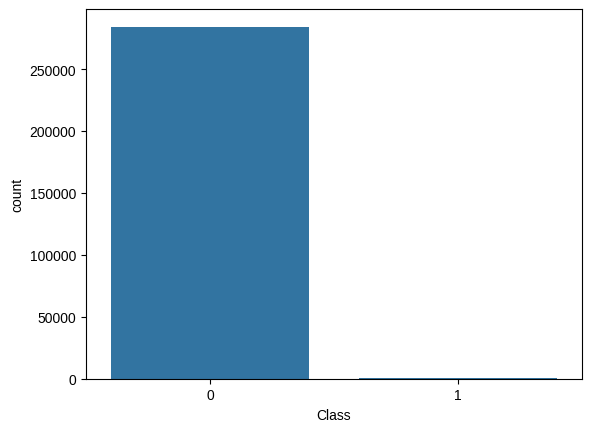

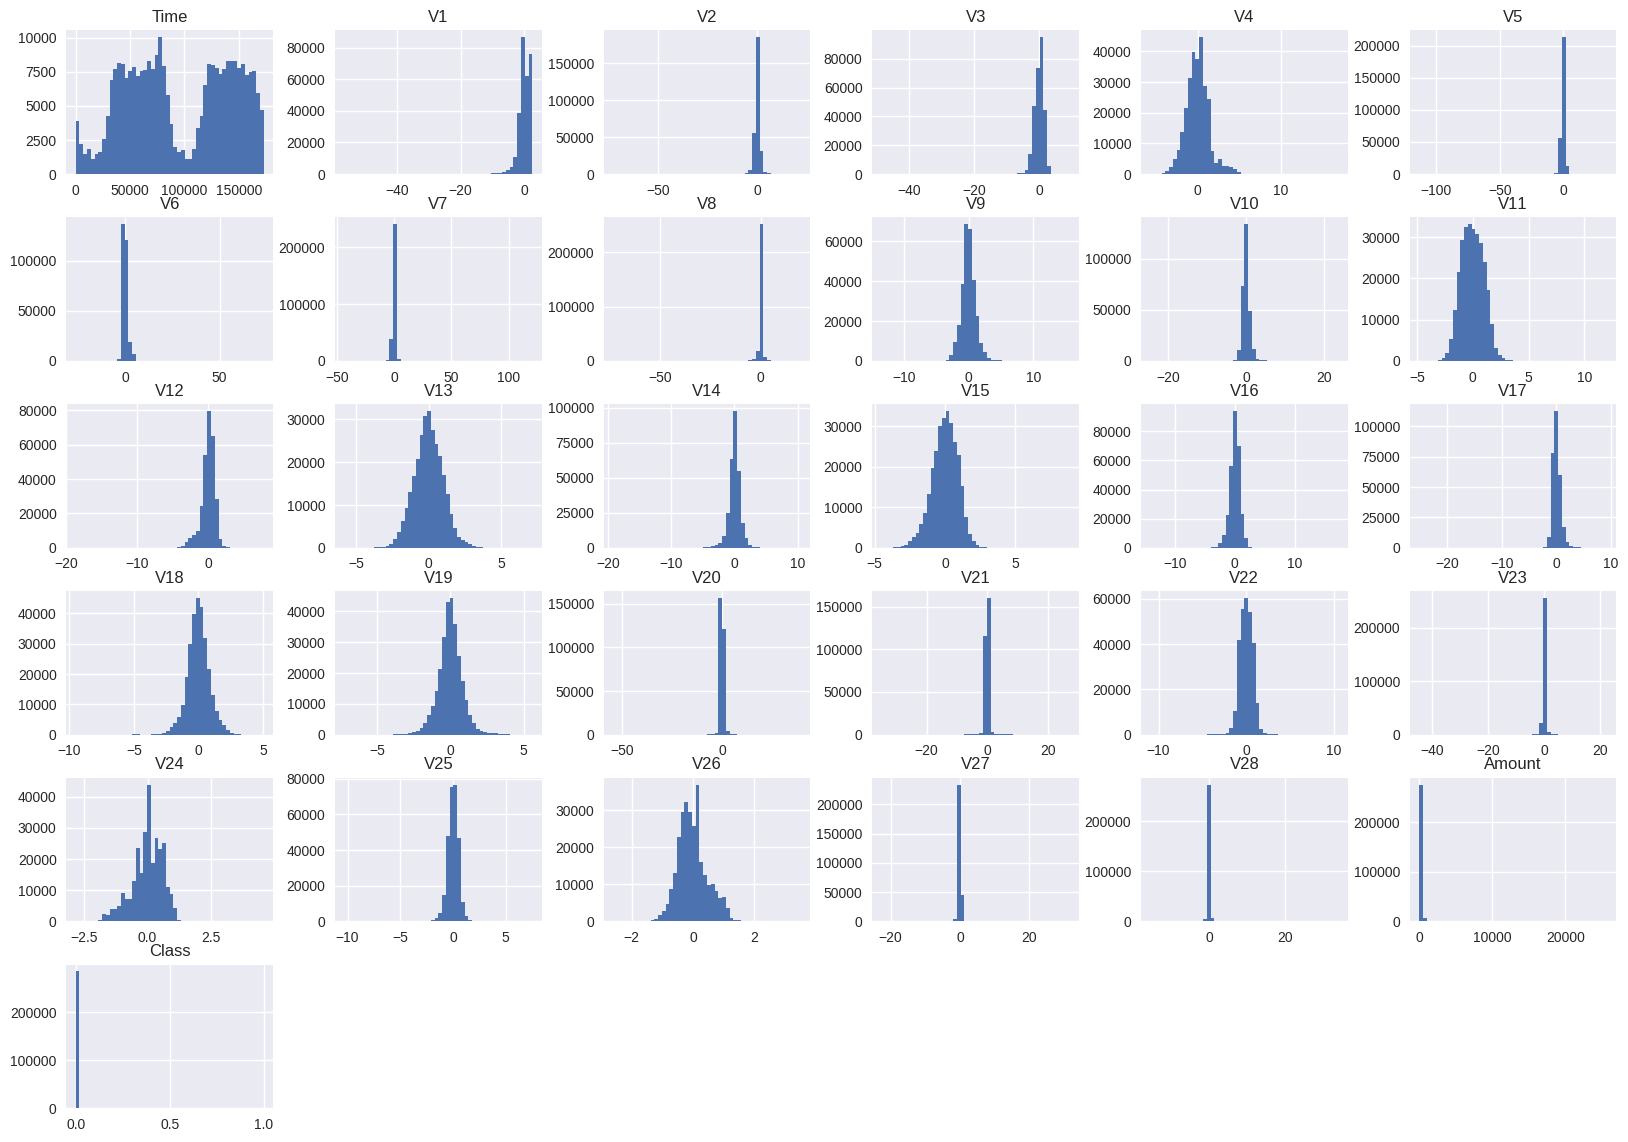

In [4]:
visualise(df)

In [5]:
x_train,x_test,y_train,y_test = trainsplit(df)

# **USING THE CLASSS WEIGHTZZZZZZZZZ!!!!!**

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best params {'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__criterion': 'gini'}
the best score AUC 0.5654163426398023


/tmp/ipykernel_17/3079974070.py:195: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


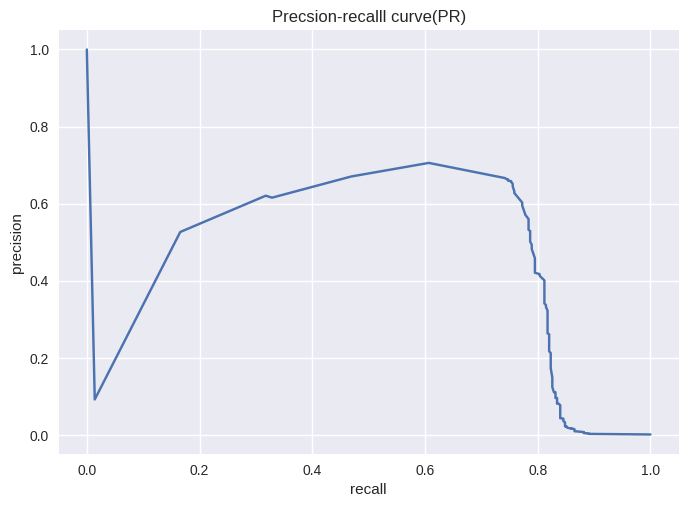

the acccueacy 0.0756293669463853
[[ 6331 78976]
 [    5   131]]


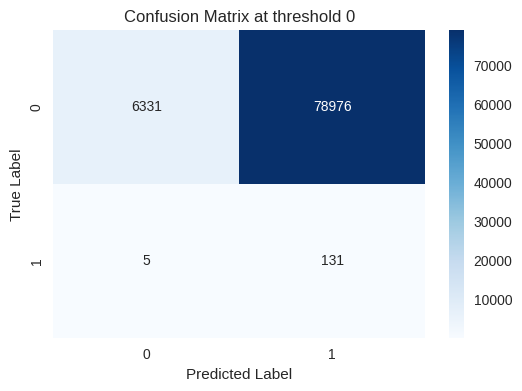

              precision    recall  f1-score   support

           0       1.00      0.07      0.14     85307
           1       0.00      0.96      0.00       136

    accuracy                           0.08     85443
   macro avg       0.50      0.52      0.07     85443
weighted avg       1.00      0.08      0.14     85443

0.31809776410485757


In [6]:
model1 = grid_with_class_weights(x_train,y_train)
threshold1 = AUC_PR(model1,x_train,y_train)
evaluate(x_test,y_test,model1,threshold1)
y_scores = model1.predict_proba(x_test)[:, 1]
precision1, recall1, thresholds = precision_recall_curve(y_test, y_scores)
auc_score = auc(recall1, precision1)
print(auc_score)

In [7]:
auc_score = auc(recall1, precision1)

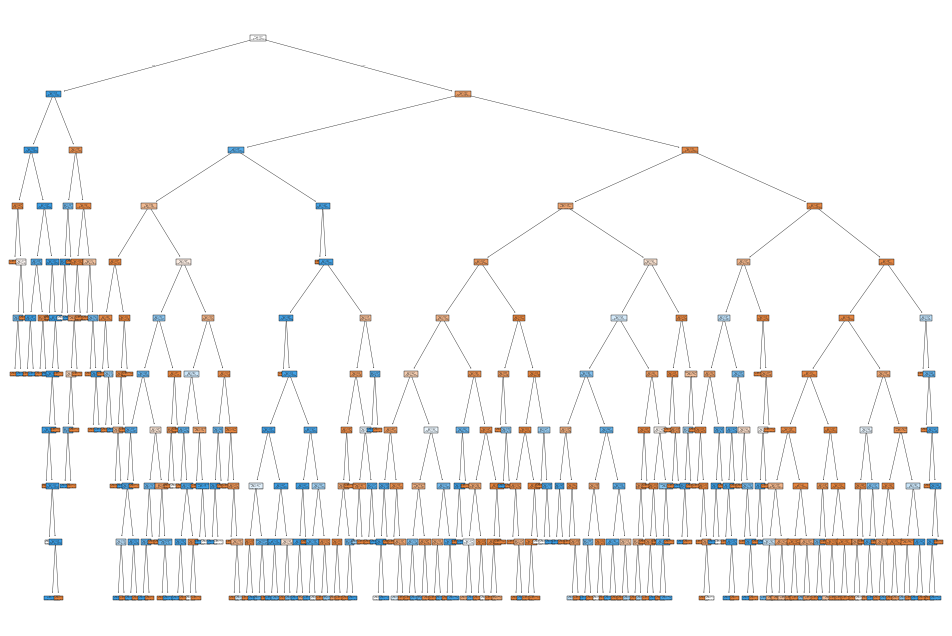

In [8]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree( model1.named_steps['model'], feature_names=x_train.columns, filled=True)
plt.show()

# **using  THE SMOTE(OVERSAMPLING)**

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best params {'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__criterion': 'gini'}
the best score AUC 0.5454597419152548


/tmp/ipykernel_17/3079974070.py:195: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


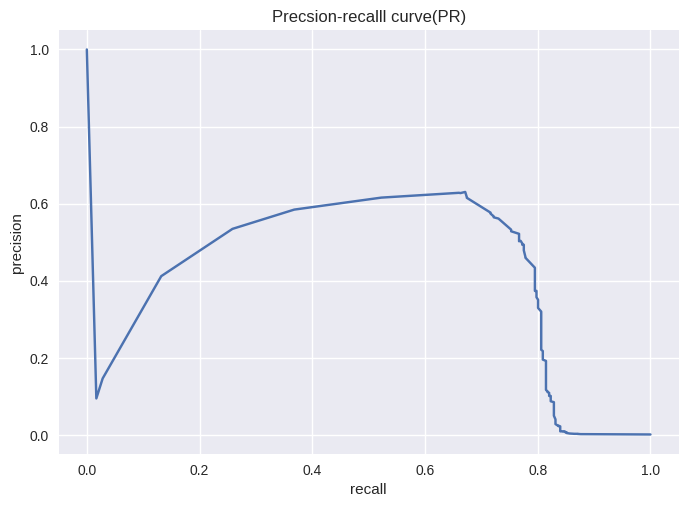

the acccueacy 0.1928069005067706
[[16349 68958]
 [   11   125]]


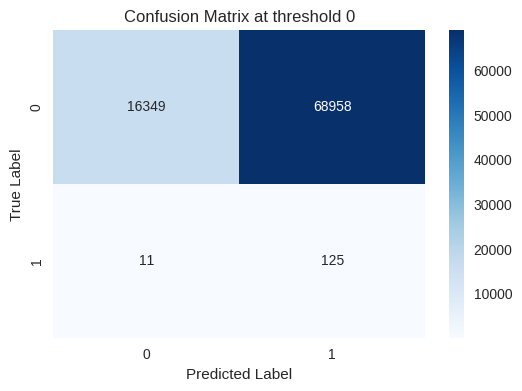

              precision    recall  f1-score   support

           0       1.00      0.19      0.32     85307
           1       0.00      0.92      0.00       136

    accuracy                           0.19     85443
   macro avg       0.50      0.56      0.16     85443
weighted avg       1.00      0.19      0.32     85443

0.3039319146355674


In [9]:
model2 = grid_with_SMOTE(x_train,y_train)
threshold2 = AUC_PR(model2,x_train,y_train)
evaluate(x_test,y_test,model2,threshold2)
y_scores = model2.predict_proba(x_test)[:, 1]
precision2, recall2, thresholds = precision_recall_curve(y_test, y_scores)
auc_score = auc(recall2, precision2)
print(auc_score)

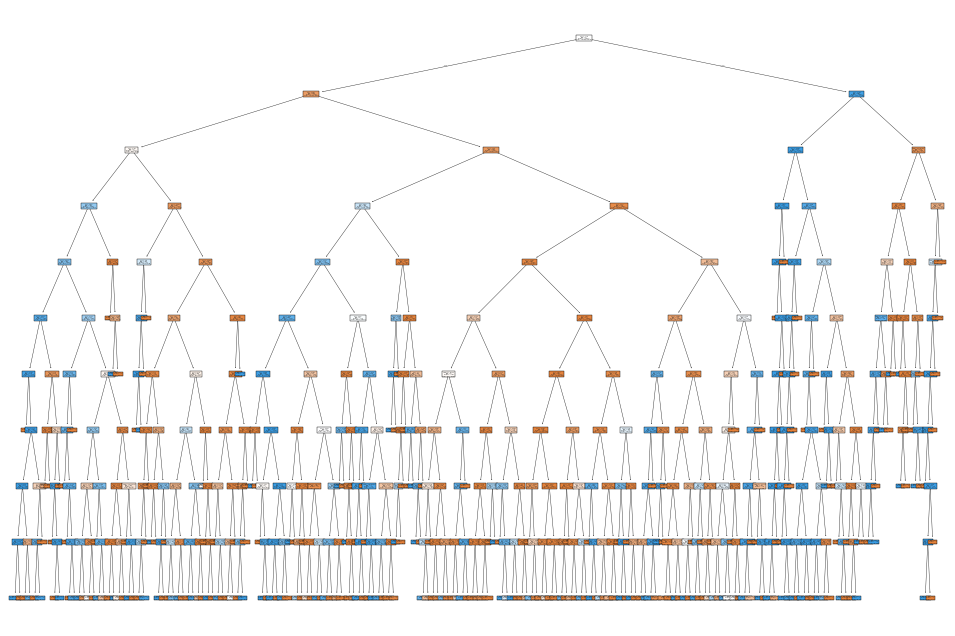

In [10]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree( model2.named_steps['model'], feature_names=x_train.columns, filled=True)
plt.show()

# **using the DOWNSAMPLING**

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best params {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
the best score AUC0.8959912456700566


/tmp/ipykernel_17/3079974070.py:195: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


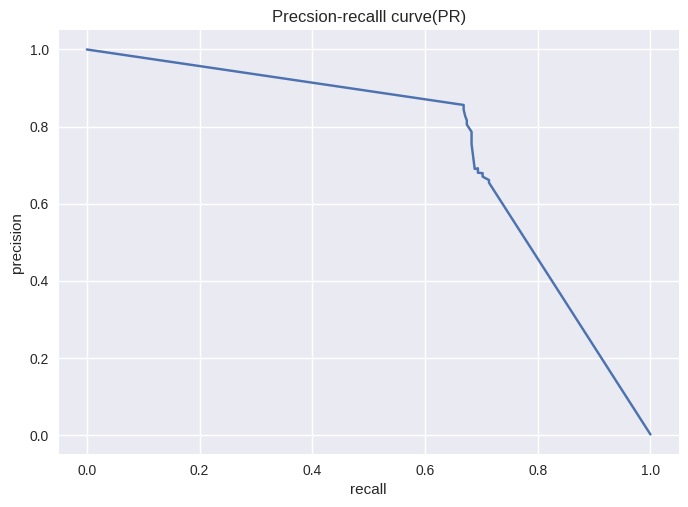

the acccueacy 0.8330934073007736
[[71053 14254]
 [    7   129]]


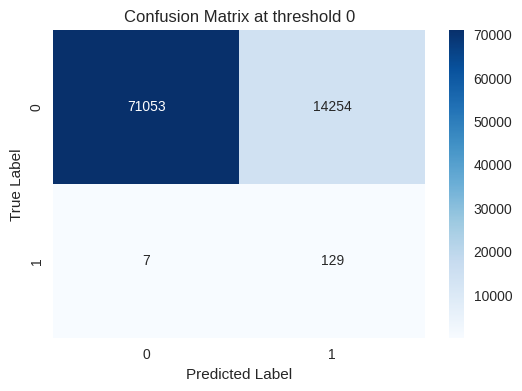

              precision    recall  f1-score   support

           0       1.00      0.83      0.91     85307
           1       0.01      0.95      0.02       136

    accuracy                           0.83     85443
   macro avg       0.50      0.89      0.46     85443
weighted avg       1.00      0.83      0.91     85443

0.44645380525569545


In [11]:
model3 = grid_with_downsampling(x_train,y_train)
threshold3 = AUC_PR(model3,x_train,y_train)
evaluate(x_test,y_test,model3,threshold3)
y_scores = model3.predict_proba(x_test)[:, 1]
precision3, recall3, thresholds = precision_recall_curve(y_test, y_scores)
auc_score = auc(recall3, precision3)
print(auc_score)

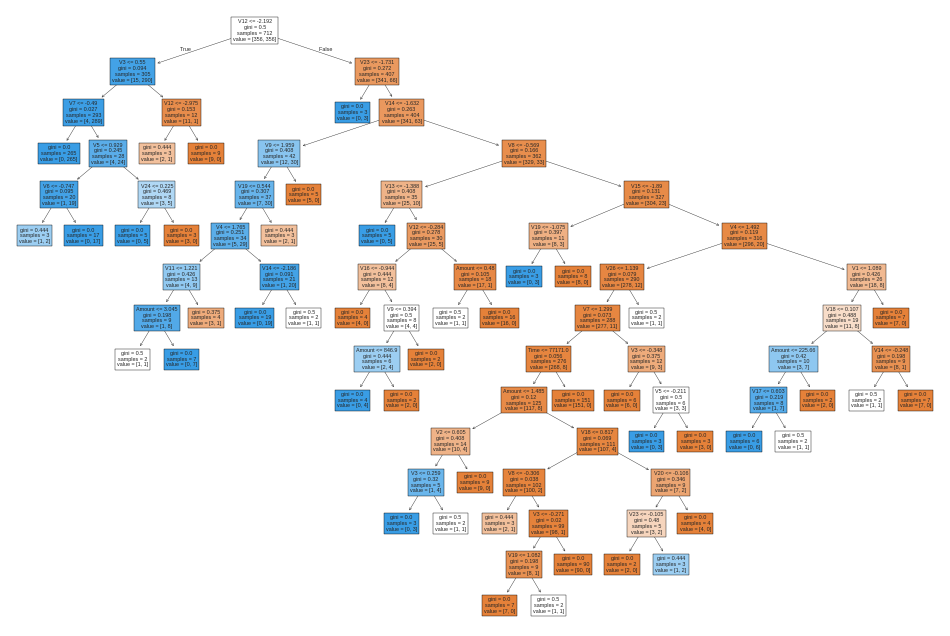

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(model3, feature_names=x_train.columns, filled=True)
plt.show()

** *we   visualise all the three PR curves togeather**

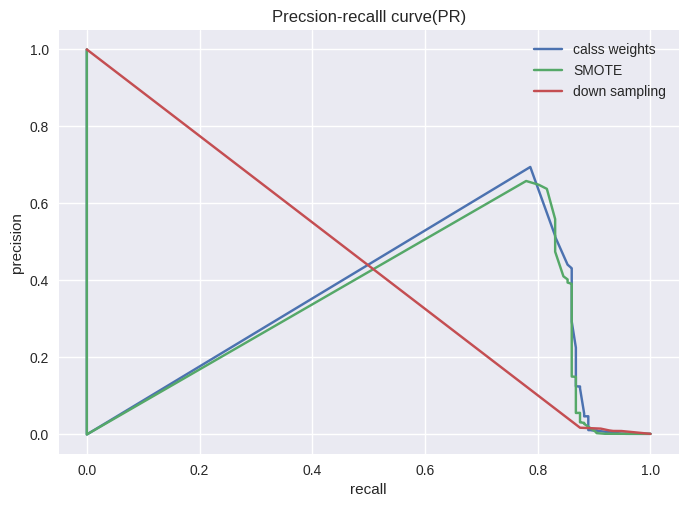

In [13]:
    #model_FPR, model_TPR,thresholds = roc_curve(y_test,y_score) //  hopeless here 
    plt.plot(recall1,precision1,label = "calss weights")
    plt.plot(recall2,precision2,label = "SMOTE")
    plt.plot(recall3,precision3,label = "down sampling")
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR)")
    plt.legend()
    plt.show()



Top Features:

V17       0.647999
V14       0.230360
V4        0.030613
V16       0.012411
V12       0.010396
V8        0.009285
Amount    0.004928
V5        0.004611
V22       0.004011
V10       0.003289
dtype: float64


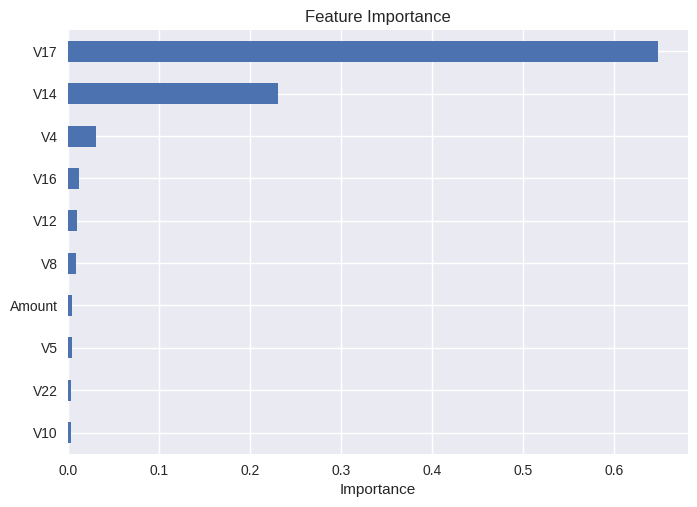

MODEL 2

Top Features:

V11    0.614333
V12    0.090128
V3     0.062997
V14    0.043979
V4     0.041835
V9     0.039205
V8     0.020699
V10    0.008514
V6     0.007457
V5     0.007304
dtype: float64


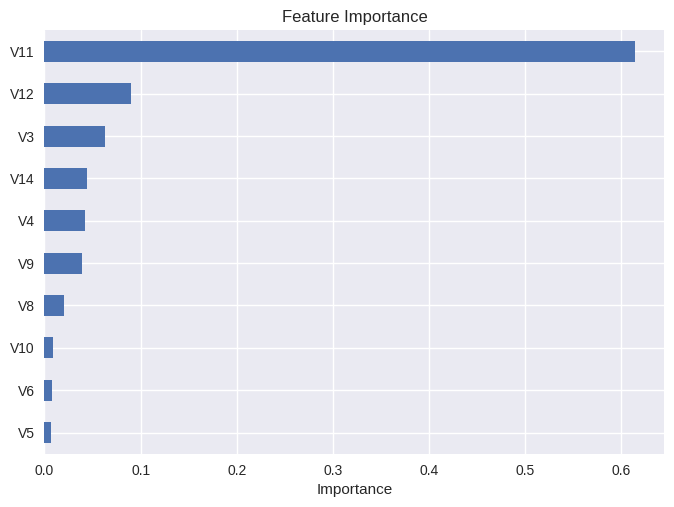

MODEL 3

Top Features:

V12       0.642938
V14       0.090950
V3        0.062097
Amount    0.024522
V9        0.020966
V19       0.019510
V13       0.017516
V23       0.015625
V4        0.013156
V5        0.012380
dtype: float64


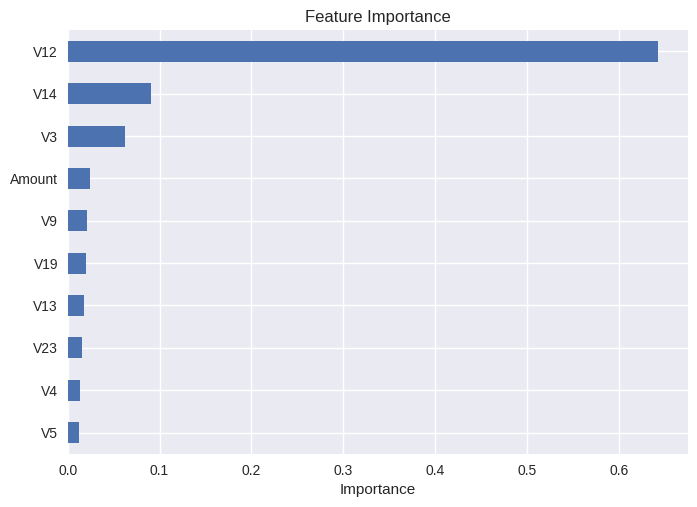

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def feature_importance(model, feature_names, top_n=10):

    # handle pipeline
    if hasattr(model, "named_steps"):
        model = model.named_steps['model']

    # get importance
    importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=feature_names)
    feat_imp = feat_imp.sort_values(ascending=False)

    print("\nTop Features:\n")
    print(feat_imp.head(top_n))

    # plot
    feat_imp.head(top_n).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.show()

    return feat_imp
    print("MODEL 1")
fi1 = feature_importance(model1, x_train.columns)

print("MODEL 2")
fi2 = feature_importance(model2, x_train.columns)

print("MODEL 3")
fi3 = feature_importance(model3, x_train.columns)